This project is a sample for modeling the ability to predict if a loan will be approved based on a decision tree classified from Scikit Learn.  

This data comes from the Kaggle dataset "Eligibility Prediction for Loan" authored by Devzohaib which can be found here: https://www.kaggle.com/datasets/devzohaib/eligibility-prediction-for-loan.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load Data

In [2]:
data = pd.read_csv(r"loan-prediction.csv")

Review Data

In [3]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan Approved
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,Urban,Y
4,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,Urban,Y


In [4]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,480.000000,480.000000,480.000000,480.000000
mean,5364.231250,1581.093583,144.735417,342.050000
std,5668.251251,2617.692267,80.508164,65.212401
min,150.000000,0.000000,9.000000,36.000000
25%,2898.750000,0.000000,100.000000,360.000000
50%,3859.000000,1084.500000,128.000000,360.000000
75%,5852.500000,2253.250000,170.000000,360.000000
max,81000.000000,33837.000000,600.000000,480.000000


array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>]], dtype=object)

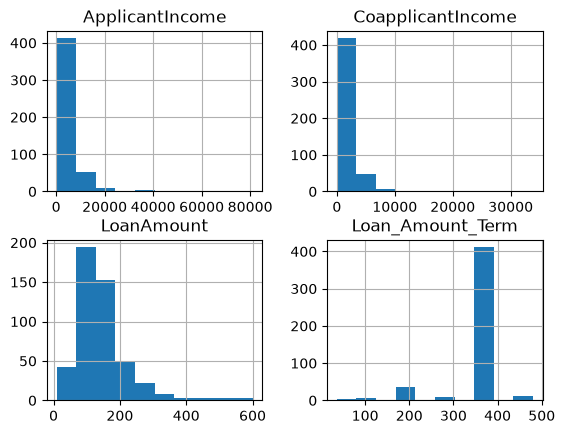

In [5]:
data.hist()

Modify Categorical Data for Modeling

In [6]:
categorized_data = pd.get_dummies(data.iloc[:, 1:], drop_first=True)

In [7]:
categorized_data.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan Approved_Y
0,4583,1508.0,128.0,360.0,True,True,True,False,False,False,False,False,False,False
1,3000,0.0,66.0,360.0,True,True,False,False,False,False,True,False,True,True
2,2583,2358.0,120.0,360.0,True,True,False,False,False,True,False,False,True,True
3,6000,0.0,141.0,360.0,True,False,False,False,False,False,False,False,True,True
4,5417,4196.0,267.0,360.0,True,True,False,True,False,False,True,False,True,True


Model Data with Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
model = DecisionTreeClassifier()
model.fit(categorized_data.iloc[:, :-1], categorized_data.iloc[:, -1])
model.score(categorized_data.iloc[:, :-1], categorized_data.iloc[:, -1])

1.0

Review Top Predictors for Loan Approval

In [ ]:
pd.Series(
    model.feature_importances_, index=categorized_data.iloc[:, :-1].columns
).sort_values(ascending=False)

ApplicantIncome            0.281319
LoanAmount                 0.250194
CoapplicantIncome          0.147165
Married_Yes                0.053669
Loan_Amount_Term           0.050487
Self_Employed_Yes          0.036388
Dependents_3+              0.033729
Education_Not Graduate     0.025992
Gender_Male                0.025516
Dependents_2               0.024482
Property_Area_Semiurban    0.024238
Property_Area_Urban        0.024167
Dependents_1               0.022654
dtype: float64

<Axes: title={'center': 'Histogram of Applicant Income for Loan Approved and Not Approved'}>

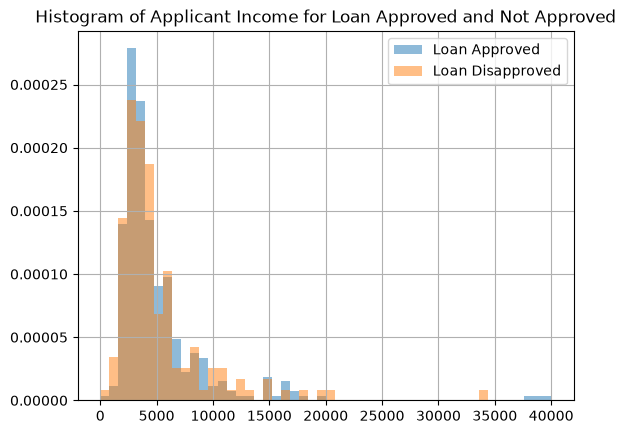

In [ ]:
plt.title("Histogram of Applicant Income for Loan Approved and Not Approved")
categorized_data.loc[
    categorized_data["Loan Approved_Y"] == 1, "ApplicantIncome"
].rename("Loan Approved").hist(
    alpha=0.5, legend=True, bins=50, density=True, range=(0, 40000)
)
categorized_data.loc[
    categorized_data["Loan Approved_Y"] == 0, "ApplicantIncome"
].rename("Loan Disapproved").hist(
    alpha=0.5, legend=True, bins=50, density=True, range=(0, 40000)
)